# Final Project Notebook: Two-Sector PVR Simulation and AKM Bridge - Tobias Hvam Hansen - Student number 202206579

**Micro and Macro Models of the Labour Market**

This notebook follows the simulation logic of the PVR lecture notebook, but extends the environment to two sectors: Energy and Non-energy.

The notebook is deliberately conservative:

- worker ability is drawn from a **common** distribution $H$;
- Energy access does **not** depend on ability;
- sector differences enter through firm productivity distributions $F_E$ and $F_N$;
- workers bargaining power is kept at the baseline $\beta = 0$;
- the structural PVR decomposition and the AKM decomposition are kept as separate objects.

The key bridge is:

$$
\text{PVR primitives} \rightarrow \text{simulate log wage panel} \rightarrow \text{estimate AKM on simulated wages}.
$$

This avoids mechanically assigning the PVR history term to worker effects.

---
## 1. Packages and plotting defaults
---

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import deque
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

rng = np.random.default_rng(20260512)

---
## 2. Empirical AKM targets
---

These targets come from the pooled largest connected component AKM estimation on the real matched employer employee data computed in the .R scripts, followed by sectoral decomposition.

In [171]:
dTarget_mean_log_wage_nonenergy = 4.748942735
dTarget_mean_log_wage_energy = 5.097628951

dTarget_worker_share_nonenergy = 0.549511
dTarget_worker_share_energy = 0.805977

dTarget_firm_share_nonenergy = 0.188010
dTarget_firm_share_energy = 0.061156

dTarget_sorting_nonenergy = 0.081121
dTarget_sorting_energy = -0.060900

dtTargets = pd.DataFrame({
    "sector_name": ["Energy", "Non-energy"],
    "mean_log_wage_target": [dTarget_mean_log_wage_energy, dTarget_mean_log_wage_nonenergy],
    "worker_share_target": [dTarget_worker_share_energy, dTarget_worker_share_nonenergy],
    "firm_share_target": [dTarget_firm_share_energy, dTarget_firm_share_nonenergy],
    "sorting_share_target": [dTarget_sorting_energy, dTarget_sorting_nonenergy],
})

dtTargets

,sector_name,mean_log_wage_target,worker_share_target,firm_share_target,sorting_share_target
0,Energy,5.097629,0.805977,0.061156,-0.060900
1,Non-energy,4.748943,0.549511,0.188010,0.081121


---
## 3. PVR primitives
---

The baseline PVR wage equation is

$$
\log \phi(\varepsilon,q,p)
=
\log \varepsilon
+
\log q
-
\frac{\lambda_1}{\rho+\delta}
\int_q^p \frac{1-F(x)}{x}\,dx.
$$

Equivalently,

$$
\log \phi(\varepsilon,q,p)
=
\log \varepsilon
+
\frac{\lambda_1}{\rho+\delta}I(p)
+
\left[\log q-\frac{\lambda_1}{\rho+\delta}I(q)\right],
$$

where $I(z)=\int_z^{\bar p}\frac{1-F(x)}{x}\,dx$. In this two-sector notebook, $F$ is the pooled offer distribution induced by constant sector-offer probabilities and sector-specific firm productivity distributions.

### 3.1 Core parameters

In [172]:
# ── Core PVR parameters, monthly units ──
rho   = 0.05 / 12     # monthly discount rate
delta = 0.02          # exogenous separation rate
lam0  = 0.20          # offer/contact rate while unemployed
lam1  = 0.05          # offer/contact rate while employed
b     = 0.50          # unemployment-income / reservation-productivity lower bound

# Baseline sequential auction case used in the project.
beta_barg = 0.0

# ── Simulation controls ──
iNWorkers = 4000
iBurnMonths = 60
iPanelMonths = 96
iSeed = 20260512

# Constant sector access. This is deliberately independent of ability.
dProbEnergyOffer = 0.08

# Firm counts.
iNFirmsEnergy = 80
iNFirmsNonEnergy = 920

print("Baseline beta:", beta_barg)
print("Energy offer probability:", dProbEnergyOffer)

Baseline beta: 0.0
Energy offer probability: 0.08


### 3.2 Common worker heterogeneity

Worker ability is common across sectors:

$$
\varepsilon_i = 1 + \chi_3 X_i,\qquad X_i\sim \operatorname{Beta}(\chi_1,\chi_2).
$$



In [173]:
# Common worker ability distribution.
chi1_eps = 0.7
chi2_eps = 0.7
chi3_eps = 20.0

eps_min = 1.0
eps_max = eps_min + chi3_eps

iGrid = 600
eps_grid = np.linspace(eps_min, eps_max, iGrid)
eps_x = (eps_grid - eps_min) / chi3_eps
H_pdf = stats.beta.pdf(eps_x, chi1_eps, chi2_eps) / chi3_eps
H_cdf = stats.beta.cdf(eps_x, chi1_eps, chi2_eps)

print(f"Ability support: [{eps_min:.2f}, {eps_max:.2f}]")

Ability support: [1.00, 21.00]


### 3.3 Sector-specific firm productivity distributions

Firms differ by sector. Energy is allowed to have a more compressed firm-productivity distribution:

$$
p_j \mid s=E \sim F_E,\qquad p_j\mid s=N \sim F_N.
$$

In [174]:
# Firm productivity support.
p_min = b
p_max = 3.50

# Tunable sector-specific firm-productivity parameters.
# Larger equal beta parameters imply a more compressed distribution around the midpoint.
xi1_E = 35.0 # 25.0
xi2_E = 35.0 # 25.0

xi1_N = 2.8 # 2.2
xi2_N = 2.8 # 2.2

dSectorName = {0: "Energy", 1: "Non-energy"}
dSectorCode = {"Energy": 0, "Non-energy": 1}

p_grid = np.linspace(p_min, p_max, iGrid)
p_x = (p_grid - p_min) / (p_max - p_min)

F_pdf_E = stats.beta.pdf(p_x, xi1_E, xi2_E) / (p_max - p_min)
F_cdf_E = stats.beta.cdf(p_x, xi1_E, xi2_E)

F_pdf_N = stats.beta.pdf(p_x, xi1_N, xi2_N) / (p_max - p_min)
F_cdf_N = stats.beta.cdf(p_x, xi1_N, xi2_N)

# Pooled offer CDF/PDF induced by constant sector access.
F_pdf_offer = dProbEnergyOffer * F_pdf_E + (1.0 - dProbEnergyOffer) * F_pdf_N
F_cdf_offer = dProbEnergyOffer * F_cdf_E + (1.0 - dProbEnergyOffer) * F_cdf_N

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

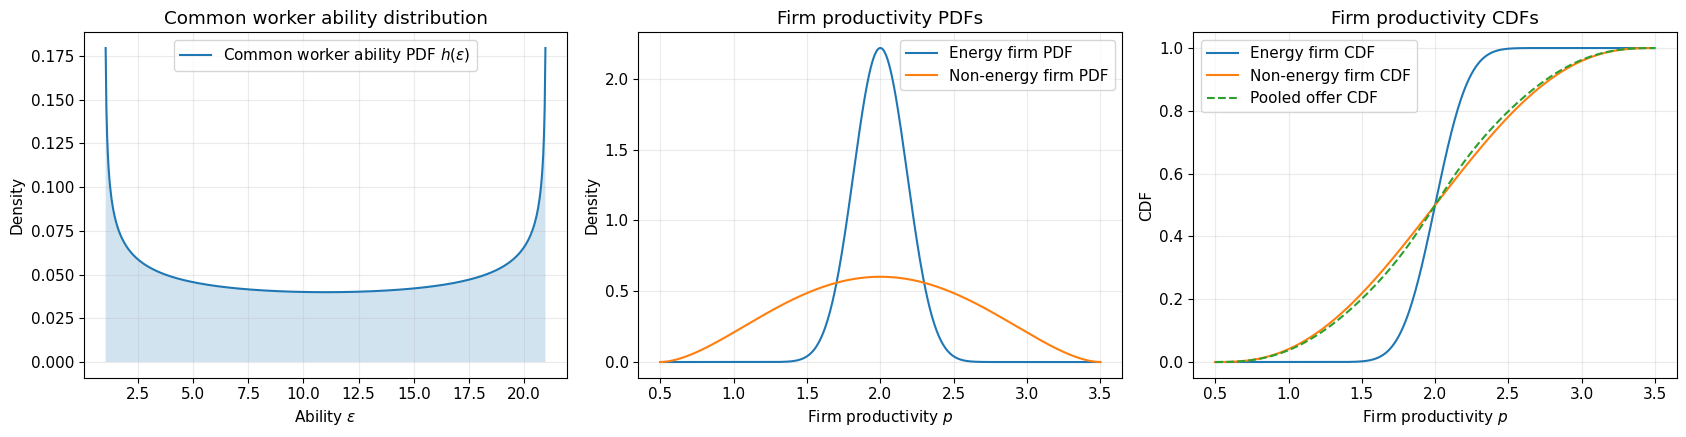

In [128]:
# ── Plot common worker heterogeneity and sector-specific firm distributions ──
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ax = axes[0]
ax.plot(eps_grid, H_pdf, label=r"Common worker ability PDF $h(\varepsilon)$")
ax.fill_between(eps_grid, H_pdf, alpha=0.20)
ax.set_title("Common worker ability distribution")
ax.set_xlabel(r"Ability $\varepsilon$")
ax.set_ylabel("Density")
ax.legend()

ax = axes[1]
ax.plot(p_grid, F_pdf_E, label="Energy firm PDF")
ax.plot(p_grid, F_pdf_N, label="Non-energy firm PDF")
ax.set_title("Firm productivity PDFs")
ax.set_xlabel("Firm productivity $p$")
ax.set_ylabel("Density")
ax.legend()

ax = axes[2]
ax.plot(p_grid, F_cdf_E, label="Energy firm CDF")
ax.plot(p_grid, F_cdf_N, label="Non-energy firm CDF")
ax.plot(p_grid, F_cdf_offer, linestyle="--", label="Pooled offer CDF")
ax.set_title("Firm productivity CDFs")
ax.set_xlabel("Firm productivity $p$")
ax.set_ylabel("CDF")
ax.legend()

plt.tight_layout()
plt.savefig("firm_productivity_distribution.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("firm_productivity_distribution.png")
plt.show()

### 3.4 Offer distribution and integral objects

The PVR wage equation uses the distribution of outside offers. Since sector access is constant, the pooled offer distribution is

$$
F(p)=\pi_E F_E(p)+(1-\pi_E)F_N(p).
$$

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

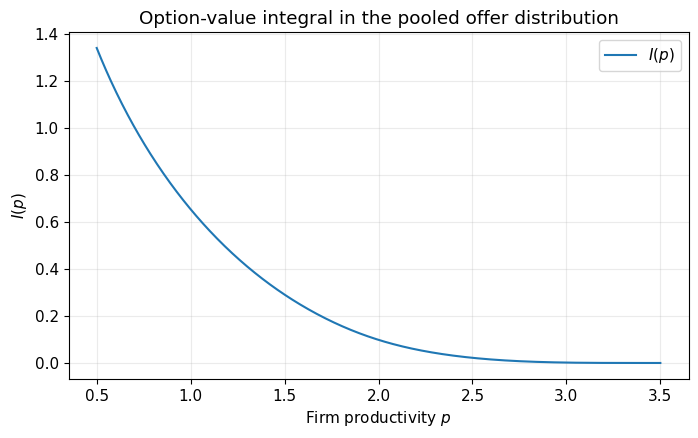

In [176]:
def compute_I_grid(vGrid, vF):
    '''Compute I(z)=int_z^pmax (1-F(x))/x dx on a grid.'''
    vIntegrand = (1.0 - vF) / vGrid
    vDx = np.diff(vGrid)
    vArea = 0.5 * (vIntegrand[:-1] + vIntegrand[1:]) * vDx
    vI = np.zeros_like(vGrid)
    vI[:-1] = np.cumsum(vArea[::-1])[::-1]
    return vI

I_grid = compute_I_grid(p_grid, F_cdf_offer)

def F_offer(p):
    return np.interp(p, p_grid, F_cdf_offer, left=0.0, right=1.0)

def I_offer(p):
    return np.interp(p, p_grid, I_grid, left=I_grid[0], right=0.0)

plt.figure(figsize=(8, 4.5))
plt.plot(p_grid, I_grid, label=r"$I(p)$")
plt.xlabel("Firm productivity $p$")
plt.ylabel(r"$I(p)$")
plt.title("Option-value integral in the pooled offer distribution")
plt.legend()

plt.savefig("option_value.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("option_value.png")

plt.show()

---
## 4. PVR wage equation and key mechanisms
---

In [177]:
def log_phi(eps, q, p):
    '''
    Baseline beta=0 PVR log wage.
    q is the worker's outside option / last best competing firm.
    p is the current employer productivity.
    '''
    q = np.asarray(q)
    p = np.asarray(p)
    return (
        np.log(eps)
        + np.log(q)
        - lam1 / (rho + delta) * (I_offer(q) - I_offer(p))
    )

def pvr_components(eps, q, p):
    '''Return structural PVR worker, firm, and history components.'''
    vWorker = np.log(eps)
    vFirm = lam1 / (rho + delta) * I_offer(p)
    vHistory = np.log(q) - lam1 / (rho + delta) * I_offer(q)
    return vWorker, vFirm, vHistory

### 4.1 Wage surface

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

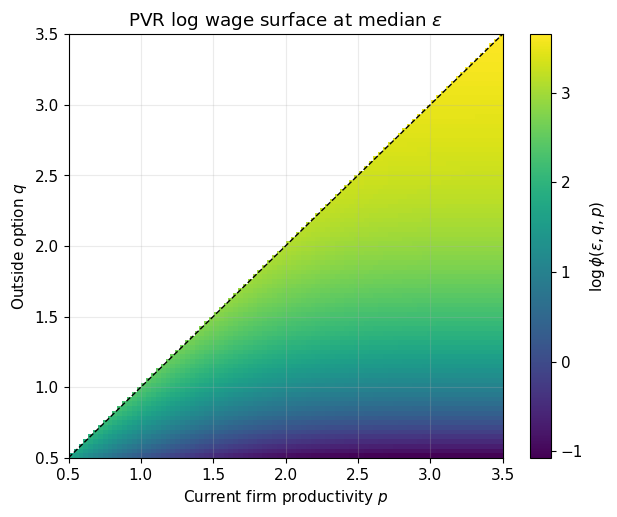

In [178]:
eps_med = 1.0 + chi3_eps * stats.beta.median(chi1_eps, chi2_eps)

nHeat = 90
q_heat = np.linspace(p_min, p_max, nHeat)
p_heat = np.linspace(p_min, p_max, nHeat)
Z = np.full((nHeat, nHeat), np.nan)

for iQ, qVal in enumerate(q_heat):
    for iP, pVal in enumerate(p_heat):
        if qVal <= pVal:
            Z[iQ, iP] = log_phi(eps_med, qVal, pVal)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(
    Z,
    origin="lower",
    extent=[p_min, p_max, p_min, p_max],
    aspect="auto",
)
ax.plot([p_min, p_max], [p_min, p_max], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Current firm productivity $p$")
ax.set_ylabel("Outside option $q$")
ax.set_title(r"PVR log wage surface at median $\varepsilon$")
fig.colorbar(im, ax=ax, label=r"$\log \phi(\varepsilon,q,p)$")

plt.savefig("wage_heatmap.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("wage_heatmap.png")

plt.show()

### 4.2 Starting wage from unemployment

At entry from unemployment, $q=b$. In the baseline $\beta=0$ PVR model, the starting wage can decline with current firm productivity because high productivity employers provide option value.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

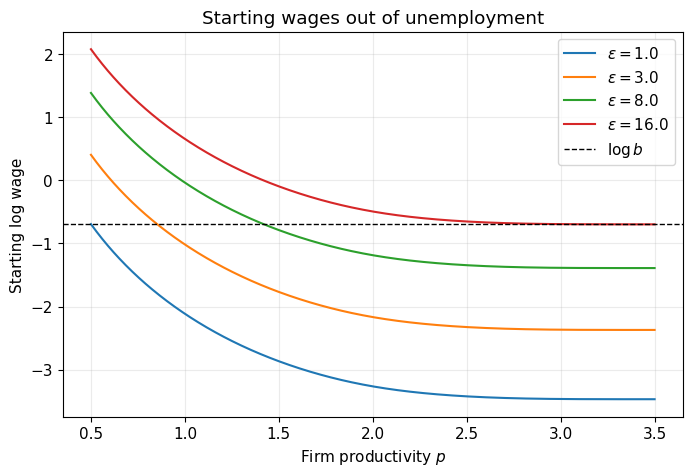

In [179]:
fig, ax = plt.subplots(figsize=(8, 5))

eps_values = [1.0, 3.0, 8.0, 16.0]
for dEps in eps_values:
    vLogW = log_phi(dEps, b, p_grid)
    ax.plot(p_grid, vLogW, label=fr"$\varepsilon={dEps:.1f}$")

ax.axhline(np.log(b), color="black", linestyle="--", linewidth=1, label=r"$\log b$")
ax.set_xlabel("Firm productivity $p$")
ax.set_ylabel("Starting log wage")
ax.set_title("Starting wages out of unemployment")
ax.legend()

plt.savefig("starting_wage_unem.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("starting_wage_unem.png")

plt.show()

### 4.3 Wage cuts at job-to-job transitions

A worker moving to a more productive firm can accept a lower current wage because the new firm offers better future renegotiation opportunities.

Old log wage: 2.9828
New log wage after J2J: 2.9327
Log wage change: -0.0501


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

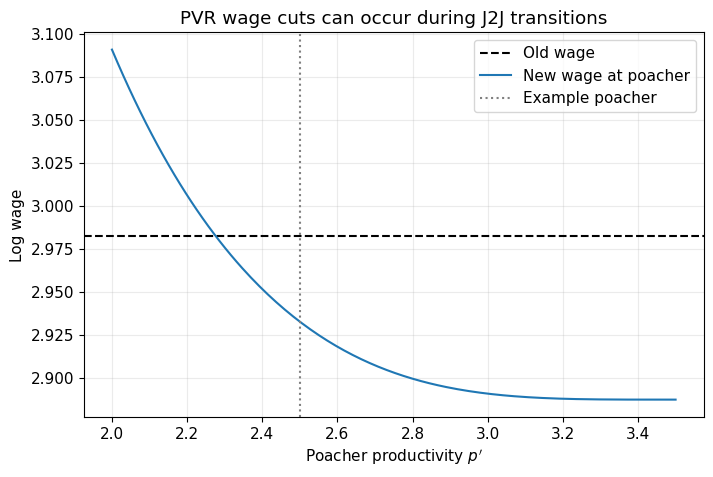

In [180]:
eps_ex = eps_med
p_old = 2.0
q_old = 1.90
p_new = 2.50

w_old = log_phi(eps_ex, q_old, p_old)
w_new = log_phi(eps_ex, p_old, p_new)

print(f"Old log wage: {w_old:.4f}")
print(f"New log wage after J2J: {w_new:.4f}")
print(f"Log wage change: {w_new - w_old:.4f}")

p_new_grid = np.linspace(p_old + 1e-4, p_max, 200)
w_new_grid = log_phi(eps_ex, p_old, p_new_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(w_old, color="black", linestyle="--", label="Old wage")
ax.plot(p_new_grid, w_new_grid, label="New wage at poacher")
ax.axvline(p_new, color="grey", linestyle=":", label="Example poacher")
ax.set_xlabel("Poacher productivity $p'$")
ax.set_ylabel("Log wage")
ax.set_title("PVR wage cuts can occur during J2J transitions")
ax.legend()

plt.savefig("wage_cuts.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("wage_cuts.png")

plt.show()

---
## 5. Steady-state objects
---

For the pooled offer distribution, the standard employed-firm distribution is

$$
G(p)=\frac{\delta F(p)}{\delta+\lambda_1[1-F(p)]}.
$$

Steady-state unemployment rate: 0.0909 (9.1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

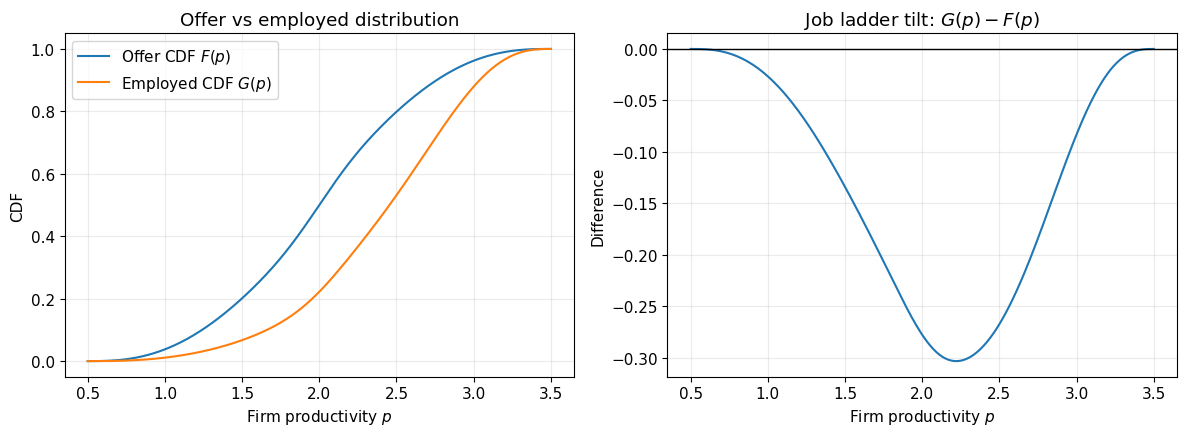

In [181]:
u_ss = delta / (delta + lam0)
G_cdf = delta * F_cdf_offer / (delta + lam1 * (1.0 - F_cdf_offer))
G_cdf = np.clip(G_cdf, 0.0, 1.0)

print(f"Steady-state unemployment rate: {u_ss:.4f} ({100*u_ss:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(p_grid, F_cdf_offer, label="Offer CDF $F(p)$")
axes[0].plot(p_grid, G_cdf, label="Employed CDF $G(p)$")
axes[0].set_title("Offer vs employed distribution")
axes[0].set_xlabel("Firm productivity $p$")
axes[0].set_ylabel("CDF")
axes[0].legend()

axes[1].plot(p_grid, G_cdf - F_cdf_offer)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Job ladder tilt: $G(p)-F(p)$")
axes[1].set_xlabel("Firm productivity $p$")
axes[1].set_ylabel("Difference")

plt.tight_layout()

plt.savefig("steady.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("steady.png")

plt.show()

---
## 6. Continuous-time two-sector simulation
---

We simulate worker careers using the competing-risks structure:

- unemployed workers receive offers at rate $\lambda_0$;
- employed workers receive useful outside offers at rate $\lambda_1[1-F(q)]$;
- jobs separate exogenously at rate $\delta$;
- if an outside offer is below the current employer but above $q$, the worker renegotiates;
- if an outside offer is above the current employer, the worker moves job-to-job.

In [182]:
def build_firm_table(rng):
    '''Draw a finite population of Energy and Non-energy firms.'''
    vXE = rng.beta(xi1_E, xi2_E, size=iNFirmsEnergy)
    vXN = rng.beta(xi1_N, xi2_N, size=iNFirmsNonEnergy)

    vPE = p_min + (p_max - p_min) * vXE
    vPN = p_min + (p_max - p_min) * vXN

    dtFirm = pd.DataFrame({
        "firm_id": np.arange(iNFirmsEnergy + iNFirmsNonEnergy),
        "sector": np.r_[np.zeros(iNFirmsEnergy, dtype=int), np.ones(iNFirmsNonEnergy, dtype=int)],
        "sector_name": ["Energy"] * iNFirmsEnergy + ["Non-energy"] * iNFirmsNonEnergy,
        "p": np.r_[vPE, vPN],
    })
    return dtFirm


def build_offer_weights(dtFirm):
    '''Constant sector access, uniform firm draw within sector.'''
    vWeight = np.zeros(len(dtFirm))
    vMaskE = dtFirm["sector"].to_numpy() == 0
    vMaskN = ~vMaskE
    vWeight[vMaskE] = dProbEnergyOffer / vMaskE.sum()
    vWeight[vMaskN] = (1.0 - dProbEnergyOffer) / vMaskN.sum()
    return vWeight / vWeight.sum()


def make_empirical_offer_functions(dtFirm, vWeight, iGridLocal=4000):
    '''Construct empirical F and I from the finite firm population and offer weights.'''
    vP = dtFirm["p"].to_numpy()
    vOrder = np.argsort(vP)
    vPSorted = vP[vOrder]
    vWSorted = vWeight[vOrder]
    vCumW = np.concatenate(([0.0], np.cumsum(vWSorted)))

    vGrid = np.linspace(vP.min(), vP.max(), iGridLocal)
    vRight = np.searchsorted(vPSorted, vGrid, side="right")
    vFGrid = vCumW[vRight]
    vIGrid = compute_I_grid(vGrid, vFGrid)

    def fF(z):
        return np.interp(z, vGrid, vFGrid, left=0.0, right=1.0)

    def fI(z):
        return np.interp(z, vGrid, vIGrid, left=vIGrid[0], right=0.0)

    return fF, fI, vGrid, vFGrid, vIGrid

In [183]:
def simulate_two_sector_pvr():
    '''Simulate spells, monthly panel, and event records from the two-sector PVR model.'''
    rngSim = np.random.default_rng(iSeed)

    dtFirm = build_firm_table(rngSim)
    vOfferWeight = build_offer_weights(dtFirm)
    fF_emp, fI_emp, vGridEmp, vFEmp, vIEmp = make_empirical_offer_functions(dtFirm, vOfferWeight)

    vFirmP = dtFirm["p"].to_numpy()

    def draw_offer_any():
        iRow = int(rngSim.choice(len(dtFirm), p=vOfferWeight))
        sr = dtFirm.iloc[iRow]
        return int(sr["firm_id"]), int(sr["sector"]), sr["sector_name"], float(sr["p"])

    def draw_offer_above(dQ):
        vW = vOfferWeight.copy()
        vW[vFirmP <= dQ + 1e-12] = 0.0
        dSum = vW.sum()
        if dSum <= 0:
            return None
        iRow = int(rngSim.choice(len(dtFirm), p=vW / dSum))
        sr = dtFirm.iloc[iRow]
        return int(sr["firm_id"]), int(sr["sector"]), sr["sector_name"], float(sr["p"])

    def log_phi_emp(dEps, dQ, dP):
        return (
            np.log(dEps)
            + np.log(dQ)
            - lam1 / (rho + delta) * (float(fI_emp(dQ)) - float(fI_emp(dP)))
        )

    vEps = 1.0 + chi3_eps * rngSim.beta(chi1_eps, chi2_eps, size=iNWorkers)
    vWorkerType = pd.qcut(vEps, q=3, labels=["Low", "Medium", "High"]).astype(str)

    iTotalMonths = iBurnMonths + iPanelMonths
    vRecordTimes = np.arange(iBurnMonths, iTotalMonths) + 0.5

    lSpellRows = []
    lPanelRows = []
    lEventRows = []
    iSpellId = 0

    for iWorker in range(iNWorkers):
        dTime = 0.0
        iRecord = 0
        sState = "U"
        iFirm = -1
        iSector = -1
        sSectorName = "Unemployed"
        dP = np.nan
        dQ = b

        while dTime < iTotalMonths:
            if sState == "U":
                dDuration = rngSim.exponential(1.0 / lam0)
                dNext = dTime + dDuration

                while iRecord < len(vRecordTimes) and vRecordTimes[iRecord] < dNext:
                    iRecord += 1

                if dNext >= iTotalMonths:
                    break

                iFirm, iSector, sSectorName, dP = draw_offer_any()
                dQ = b
                dLogWage = log_phi_emp(vEps[iWorker], dQ, dP)
                sState = "E"
                lEventRows.append({
                    "worker_id": iWorker,
                    "time": dNext,
                    "event": "U2J",
                    "firm_id": iFirm,
                    "sector": iSector,
                    "sector_name": sSectorName,
                    "p": dP,
                    "q": dQ,
                    "log_wage": dLogWage,
                })
                dTime = dNext

            else:
                dFQ = float(fF_emp(dQ))
                dHazard = delta + lam1 * (1.0 - dFQ)
                dDuration = rngSim.exponential(1.0 / dHazard)
                dNext = dTime + dDuration

                dLogWage = log_phi_emp(vEps[iWorker], dQ, dP)
                iStartSpell = iSpellId

                while iRecord < len(vRecordTimes) and vRecordTimes[iRecord] < dNext:
                    dMonthTime = vRecordTimes[iRecord]
                    iMonth = int(dMonthTime - iBurnMonths)
                    dTenure = dMonthTime - dTime
                    vWorkerComp = np.log(vEps[iWorker])
                    vFirmComp = lam1 / (rho + delta) * float(fI_emp(dP))
                    vHistComp = np.log(dQ) - lam1 / (rho + delta) * float(fI_emp(dQ))

                    lPanelRows.append({
                        "worker_id": iWorker,
                        "worker_type": vWorkerType[iWorker],
                        "month": iMonth,
                        "firm_id": iFirm,
                        "sector": iSector,
                        "sector_name": sSectorName,
                        "eps": vEps[iWorker],
                        "p_current": dP,
                        "q_current": dQ,
                        "tenure": dTenure,
                        "log_wage": dLogWage,
                        "wage": np.exp(dLogWage),
                        "pvr_worker": vWorkerComp,
                        "pvr_firm": vFirmComp,
                        "pvr_history": vHistComp,
                        "spell_id": iStartSpell,
                    })
                    iRecord += 1

                lSpellRows.append({
                    "spell_id": iSpellId,
                    "worker_id": iWorker,
                    "worker_type": vWorkerType[iWorker],
                    "start": dTime,
                    "end": min(dNext, iTotalMonths),
                    "duration": min(dNext, iTotalMonths) - dTime,
                    "firm_id": iFirm,
                    "sector": iSector,
                    "sector_name": sSectorName,
                    "eps": vEps[iWorker],
                    "p_current": dP,
                    "q_current": dQ,
                    "log_wage": dLogWage,
                    "wage": np.exp(dLogWage),
                })
                iSpellId += 1

                if dNext >= iTotalMonths:
                    break

                if rngSim.random() < delta / dHazard:
                    lEventRows.append({
                        "worker_id": iWorker,
                        "time": dNext,
                        "event": "J2U",
                        "firm_id": iFirm,
                        "sector": iSector,
                        "sector_name": sSectorName,
                        "p": dP,
                        "q": dQ,
                        "log_wage": dLogWage,
                    })
                    sState = "U"
                    iFirm = -1
                    iSector = -1
                    sSectorName = "Unemployed"
                    dP = np.nan
                    dQ = b

                else:
                    tplOffer = draw_offer_above(dQ)
                    if tplOffer is not None:
                        iFirmNew, iSectorNew, sSectorNameNew, dPNew = tplOffer

                        if dPNew <= dP + 1e-12:
                            dQ = dPNew
                            dLogWageNew = log_phi_emp(vEps[iWorker], dQ, dP)
                            lEventRows.append({
                                "worker_id": iWorker,
                                "time": dNext,
                                "event": "REN",
                                "firm_id": iFirm,
                                "sector": iSector,
                                "sector_name": sSectorName,
                                "p": dP,
                                "q": dQ,
                                "log_wage": dLogWageNew,
                            })
                        else:
                            dQOld = dQ
                            dPOld = dP
                            iFirmOld = iFirm
                            iSectorOld = iSector
                            sSectorNameOld = sSectorName
                            dLogWageOld = dLogWage

                            dQ = dP
                            iFirm = iFirmNew
                            iSector = iSectorNew
                            sSectorName = sSectorNameNew
                            dP = dPNew
                            dLogWageNew = log_phi_emp(vEps[iWorker], dQ, dP)

                            lEventRows.append({
                                "worker_id": iWorker,
                                "time": dNext,
                                "event": "J2J",
                                "old_firm_id": iFirmOld,
                                "old_sector": iSectorOld,
                                "old_sector_name": sSectorNameOld,
                                "old_p": dPOld,
                                "old_q": dQOld,
                                "old_log_wage": dLogWageOld,
                                "firm_id": iFirm,
                                "sector": iSector,
                                "sector_name": sSectorName,
                                "p": dP,
                                "q": dQ,
                                "log_wage": dLogWageNew,
                                "cross_sector": iSectorOld != iSector,
                            })

                dTime = dNext

    dtSpells = pd.DataFrame(lSpellRows)
    dtPanel = pd.DataFrame(lPanelRows)
    dtEvents = pd.DataFrame(lEventRows)

    dtPanel["pvr_check_sum"] = dtPanel["pvr_worker"] + dtPanel["pvr_firm"] + dtPanel["pvr_history"]
    dtPanel["pvr_check_error"] = dtPanel["log_wage"] - dtPanel["pvr_check_sum"]

    return dtFirm, dtSpells, dtPanel, dtEvents, fF_emp, fI_emp, vGridEmp, vFEmp, vIEmp

In [184]:
print(f"Simulating {iNWorkers:,} workers for {iBurnMonths + iPanelMonths} months...")

dtFirm, dtSpells, dtPanel, dtEvents, fF_emp, fI_emp, vGridEmp, vFEmp, vIEmp = simulate_two_sector_pvr()

print("Monthly employed panel dimensions:", dtPanel.shape)
print("Workers observed employed:", dtPanel["worker_id"].nunique())
print("Firms observed employed:", dtPanel["firm_id"].nunique())
print("Max PVR reconstruction error:", dtPanel["pvr_check_error"].abs().max())

pd.DataFrame({
    "object": ["Spells", "Monthly employed observations", "Events"],
    "value": [len(dtSpells), len(dtPanel), len(dtEvents)]
})

Simulating 4,000 workers for 156 months...
Monthly employed panel dimensions: (349286, 18)
Workers observed employed: 4000
Firms observed employed: 1000
Max PVR reconstruction error: 8.881784197001252e-16


,object,value
0,Spells,33206
1,Monthly employed observations,349286
2,Events,44261


### 6.1 Simulation diagnostics

In [185]:
dtEventSummary = (
    dtEvents["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

dtFirmDispersion = (
    dtFirm
    .groupby("sector_name")["p"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

dtEmploymentSummary = (
    dtPanel
    .groupby("sector_name")
    .agg(
        n_obs=("log_wage", "size"),
        n_workers=("worker_id", "nunique"),
        n_firms=("firm_id", "nunique"),
        mean_log_wage=("log_wage", "mean"),
        sd_log_wage=("log_wage", "std"),
        mean_eps=("eps", "mean"),
        mean_p=("p_current", "mean"),
        mean_q=("q_current", "mean"),
    )
    .reset_index()
)

print("Event summary")
display(dtEventSummary)
print("Firm dispersion")
display(dtFirmDispersion)
print("Employment summary")
display(dtEmploymentSummary)

Event summary


,event,n
0,U2J,14699
1,J2U,11055
2,J2J,9267
3,REN,9240


Firm dispersion


,sector_name,count,mean,std,min,max
0,Energy,80,1.979216,0.158986,1.615352,2.463951
1,Non-energy,920,1.994809,0.579947,0.593758,3.415649


Employment summary


,sector_name,n_obs,n_workers,n_firms,mean_log_wage,sd_log_wage,mean_eps,mean_p,mean_q
0,Energy,19736,949,80,1.107393,1.809031,11.294573,2.022471,1.218919
1,Non-energy,329550,3995,920,1.697199,1.765560,10.923649,2.388658,1.627281


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

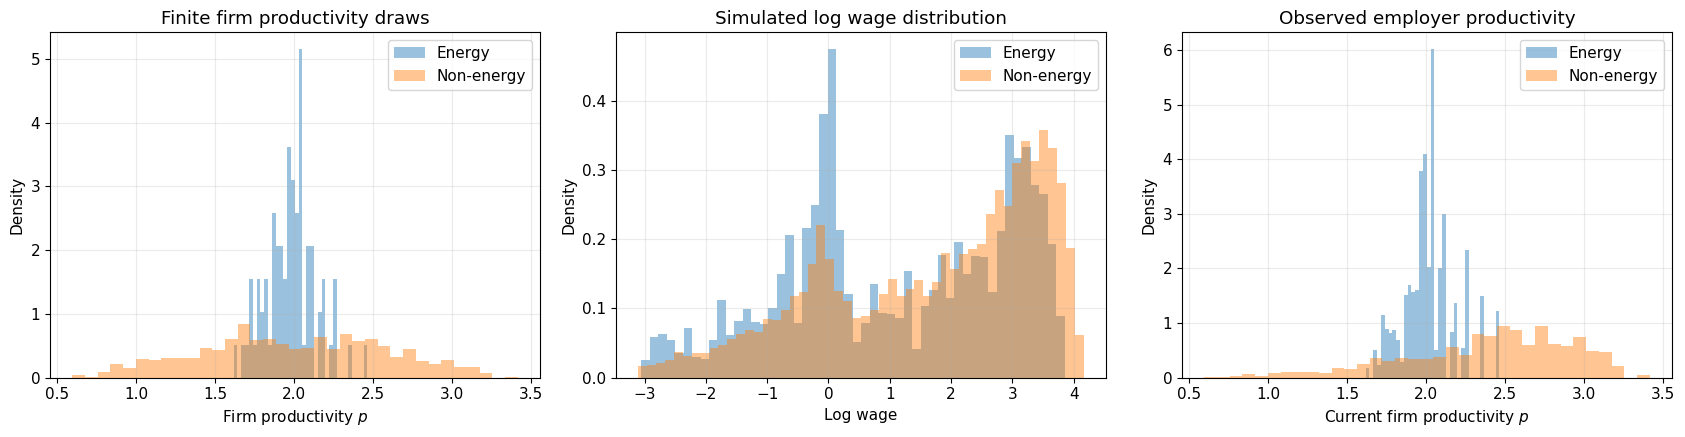

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ax = axes[0]
for sSector, dtG in dtFirm.groupby("sector_name"):
    ax.hist(dtG["p"], bins=35, density=True, alpha=0.45, label=sSector)
ax.set_title("Finite firm productivity draws")
ax.set_xlabel("Firm productivity $p$")
ax.set_ylabel("Density")
ax.legend()

ax = axes[1]
for sSector, dtG in dtPanel.groupby("sector_name"):
    ax.hist(dtG["log_wage"], bins=50, density=True, alpha=0.45, label=sSector)
ax.set_title("Simulated log wage distribution")
ax.set_xlabel("Log wage")
ax.set_ylabel("Density")
ax.legend()

ax = axes[2]
for sSector, dtG in dtPanel.groupby("sector_name"):
    ax.hist(dtG["p_current"], bins=35, density=True, alpha=0.45, label=sSector)
ax.set_title("Observed employer productivity")
ax.set_xlabel("Current firm productivity $p$")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()

plt.savefig("simulated_distributions.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("simulated_distributions.png")

plt.show()

### 6.2 Worker-type diagnostics

Worker types are diagnostic bins only. They are not used to assign sector access.

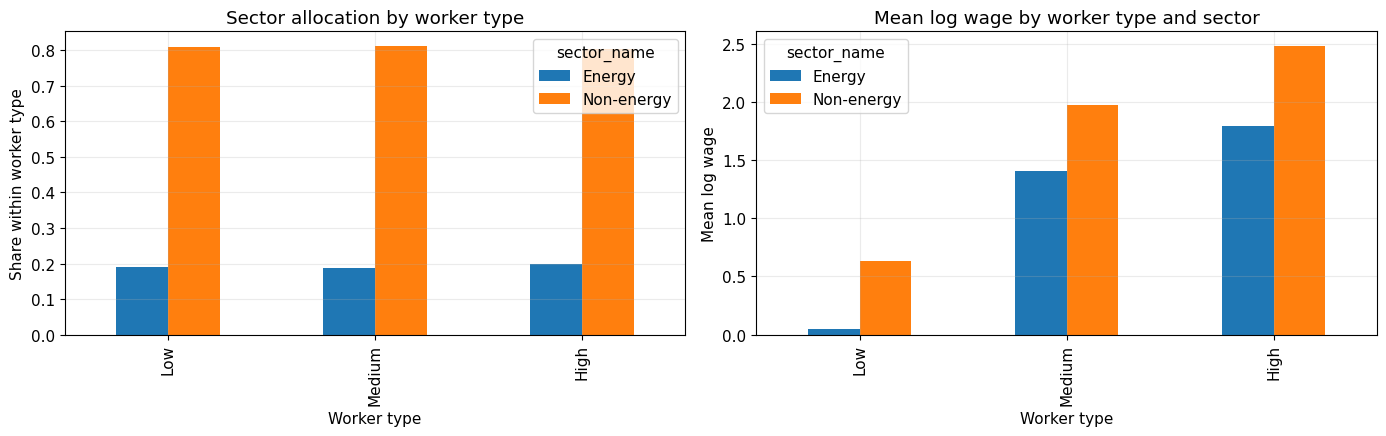

In [187]:
dtWorkerTypeSector = (
    dtPanel
    .drop_duplicates(["worker_id", "sector_name"])
    .groupby(["worker_type", "sector_name"])["worker_id"]
    .nunique()
    .reset_index(name="n_workers")
)
dtWorkerTypeSector["share"] = (
    dtWorkerTypeSector["n_workers"]
    / dtWorkerTypeSector.groupby("worker_type")["n_workers"].transform("sum")
)

dtWageByTypeSector = (
    dtPanel
    .groupby(["worker_type", "sector_name"])["log_wage"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pivot1 = dtWorkerTypeSector.pivot(index="worker_type", columns="sector_name", values="share")
pivot1.loc[["Low", "Medium", "High"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Sector allocation by worker type")
axes[0].set_xlabel("Worker type")
axes[0].set_ylabel("Share within worker type")
axes[0].legend(title="sector_name")

pivot2 = dtWageByTypeSector.pivot(index="worker_type", columns="sector_name", values="log_wage")
pivot2.loc[["Low", "Medium", "High"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Mean log wage by worker type and sector")
axes[1].set_xlabel("Worker type")
axes[1].set_ylabel("Mean log wage")
axes[1].legend(title="sector_name")

plt.tight_layout()
plt.show()

### 6.4 Wage-tenure profile

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

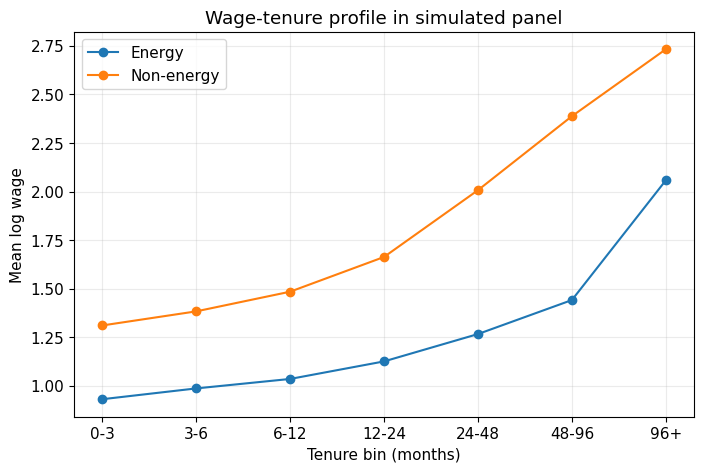

In [189]:
dtPanel["tenure_bin"] = pd.cut(
    dtPanel["tenure"],
    bins=[0, 3, 6, 12, 24, 48, 96, 10_000],
    labels=["0-3", "3-6", "6-12", "12-24", "24-48", "48-96", "96+"]
)

dtTenure = (
    dtPanel
    .groupby(["tenure_bin", "sector_name"], observed=True)["log_wage"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for sSector, dtG in dtTenure.groupby("sector_name"):
    ax.plot(dtG["tenure_bin"].astype(str), dtG["log_wage"], marker="o", label=sSector)
ax.set_xlabel("Tenure bin (months)")
ax.set_ylabel("Mean log wage")
ax.set_title("Wage-tenure profile in simulated panel")
ax.legend()

plt.savefig("wage_tenure.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("wage_tenure.png")

plt.show()

### 6.5 Event study around job-to-job transitions

J2J event counts by destination sector and wage-change type


,dest_sector,move_type,n_events
0,Energy,Wage cut,68
1,Energy,Wage increase,286
2,Non-energy,Wage cut,1140
3,Non-energy,Wage increase,4267


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

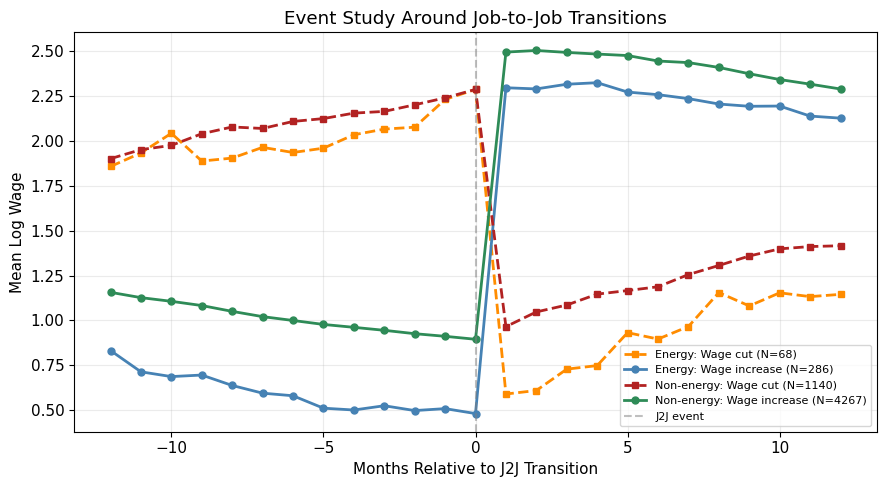

Event month 0 is the last month at the old firm.
The wage change occurs between month 0 and month 1.


In [190]:
# ── Event study around J2J transitions by destination sector and wage change ──

window = 12
iMinObs = 5  # lower threshold because Energy has fewer J2J events

df_monthly = dtPanel.sort_values(["worker_id", "month"]).copy()

# Lag variables within worker
df_monthly["lag_month"] = df_monthly.groupby("worker_id")["month"].shift(1)
df_monthly["lag_firm_id"] = df_monthly.groupby("worker_id")["firm_id"].shift(1)
df_monthly["lag_log_wage"] = df_monthly.groupby("worker_id")["log_wage"].shift(1)

# A J2J transition is observed in the first month at the new firm
df_monthly["is_j2j"] = (
    (df_monthly["month"] == df_monthly["lag_month"] + 1)
    & (df_monthly["firm_id"] != df_monthly["lag_firm_id"])
    & df_monthly["lag_firm_id"].notna()
)

# Construct J2J event dataset
df_j2j = df_monthly.loc[
    df_monthly["is_j2j"],
    [
        "worker_id",
        "month",
        "firm_id",
        "lag_firm_id",
        "sector_name",
        "log_wage",
        "lag_log_wage"
    ]
].copy()

df_j2j = df_j2j.rename(columns={
    "month": "new_month",
    "firm_id": "new_firm_id",
    "lag_firm_id": "old_firm_id",
    "sector_name": "dest_sector",
    "log_wage": "new_log_wage",
    "lag_log_wage": "old_log_wage"
})

# Event month is the last month at old firm
df_j2j["j2j_month"] = df_j2j["new_month"] - 1

# Wage change from old firm month to new firm month
df_j2j["log_wage_change"] = df_j2j["new_log_wage"] - df_j2j["old_log_wage"]
df_j2j["wage_cut"] = df_j2j["log_wage_change"] < 0
df_j2j["move_type"] = np.where(df_j2j["wage_cut"], "Wage cut", "Wage increase")


def compute_event_study(df_monthly, df_j2j_subset, window, iMinObs):
    """
    Compute mean log wage relative to J2J event month.
    Event month 0 is the last month at the old firm.
    """

    rel_wages = {k: [] for k in range(-window, window + 1)}

    for _, j2j_row in df_j2j_subset.iterrows():

        iWorker = j2j_row.worker_id
        iEventMonth = j2j_row.j2j_month

        df_wi = df_monthly[df_monthly.worker_id == iWorker]

        for k in range(-window, window + 1):

            iMonth = iEventMonth + k
            row_m = df_wi[df_wi.month == iMonth]

            if len(row_m) > 0 and not np.isnan(row_m.iloc[0].log_wage):
                rel_wages[k].append(row_m.iloc[0].log_wage)

    rel_months = []
    mean_vals = []

    for k in range(-window, window + 1):
        if len(rel_wages[k]) >= iMinObs:
            rel_months.append(k)
            mean_vals.append(np.mean(rel_wages[k]))

    return np.array(rel_months), np.array(mean_vals)


# Check event counts
dtJ2JCounts = (
    df_j2j
    .groupby(["dest_sector", "move_type"], observed=True)
    .size()
    .reset_index(name="n_events")
)

print("J2J event counts by destination sector and wage-change type")
display(dtJ2JCounts)


# Plot four lines: Energy/Non-energy x wage increase/wage cut
fig, ax = plt.subplots(figsize=(9, 5))

dStyle = {
    ("Energy", "Wage increase"): {"color": "steelblue", "marker": "o", "linestyle": "-"},
    ("Energy", "Wage cut"): {"color": "darkorange", "marker": "s", "linestyle": "--"},
    ("Non-energy", "Wage increase"): {"color": "seagreen", "marker": "o", "linestyle": "-"},
    ("Non-energy", "Wage cut"): {"color": "firebrick", "marker": "s", "linestyle": "--"},
}

for (sSector, sMoveType), df_g in df_j2j.groupby(["dest_sector", "move_type"], observed=True):

    rm, mw = compute_event_study(df_monthly, df_g, window, iMinObs)

    dThisStyle = dStyle.get(
        (sSector, sMoveType),
        {"marker": "o", "linestyle": "-"}
    )

    ax.plot(
        rm,
        mw,
        lw=2,
        markersize=5,
        label=f"{sSector}: {sMoveType} (N={len(df_g)})",
        **dThisStyle
    )

ax.axvline(0, color="gray", ls="--", alpha=0.5, label="J2J event")
ax.set_xlabel("Months Relative to J2J Transition")
ax.set_ylabel("Mean Log Wage")
ax.set_title("Event Study Around Job-to-Job Transitions")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("j2j_event_study_sector_wage_change.pdf", bbox_inches="tight")
plt.savefig("j2j_event_study_sector_wage_change.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("j2j_event_study_sector_wage_change.pdf")
files.download("j2j_event_study_sector_wage_change.png")

plt.show()

print("Event month 0 is the last month at the old firm.")
print("The wage change occurs between month 0 and month 1.")

---
## 7. Structural PVR decomposition
---

This is **not** the AKM decomposition. It decomposes the model-generated log wage into its structural terms.

In [191]:
def structural_decomposition(dtSub):
    dVarY = dtSub["log_wage"].var(ddof=0)
    dVarWorker = dtSub["pvr_worker"].var(ddof=0)
    dVarFirm = dtSub["pvr_firm"].var(ddof=0)
    dVarHistory = dtSub["pvr_history"].var(ddof=0)
    dCovWF = 2.0 * np.cov(dtSub["pvr_worker"], dtSub["pvr_firm"], ddof=0)[0, 1]
    dCovWH = 2.0 * np.cov(dtSub["pvr_worker"], dtSub["pvr_history"], ddof=0)[0, 1]
    dCovFH = 2.0 * np.cov(dtSub["pvr_firm"], dtSub["pvr_history"], ddof=0)[0, 1]
    dRecon = dtSub["pvr_worker"] + dtSub["pvr_firm"] + dtSub["pvr_history"]
    dVarResid = (dtSub["log_wage"] - dRecon).var(ddof=0)

    return {
        "var_log_wage": dVarY,
        "share_worker_struct": dVarWorker / dVarY,
        "share_firm_struct": dVarFirm / dVarY,
        "share_history_struct": dVarHistory / dVarY,
        "share_cov_worker_firm": dCovWF / dVarY,
        "share_cov_worker_history": dCovWH / dVarY,
        "share_cov_firm_history": dCovFH / dVarY,
        "share_resid_struct": dVarResid / dVarY,
        "share_total_struct": (dVarWorker + dVarFirm + dVarHistory + dCovWF + dCovWH + dCovFH + dVarResid) / dVarY,
        "max_abs_reconstruction_error": (dtSub["log_wage"] - dRecon).abs().max(),
    }

lRows = []
for sName, dtSub in [("Pooled", dtPanel)] + list(dtPanel.groupby("sector_name")):
    dOut = structural_decomposition(dtSub)
    dOut["sector_name"] = sName
    lRows.append(dOut)

dtStructDecomp = pd.DataFrame(lRows)
dtStructDecomp = dtStructDecomp[["sector_name"] + [c for c in dtStructDecomp.columns if c != "sector_name"]]
dtStructDecomp

,sector_name,var_log_wage,share_worker_struct,share_firm_struct,share_history_struct,share_cov_worker_firm,share_cov_worker_history,share_cov_firm_history,share_resid_struct,share_total_struct,max_abs_reconstruction_error
0,Pooled,3.144510,0.232241,0.025454,0.890788,0.001910,-0.002221,-0.148173,2.161864e-32,1.0,8.881784e-16
1,Energy,3.272428,0.236605,0.002094,0.791343,-0.001782,-0.007275,-0.020984,2.133522e-32,1.0,8.881784e-16
2,Non-energy,3.117193,0.233421,0.027053,0.894895,0.002119,-0.001359,-0.156130,2.176948e-32,1.0,8.881784e-16


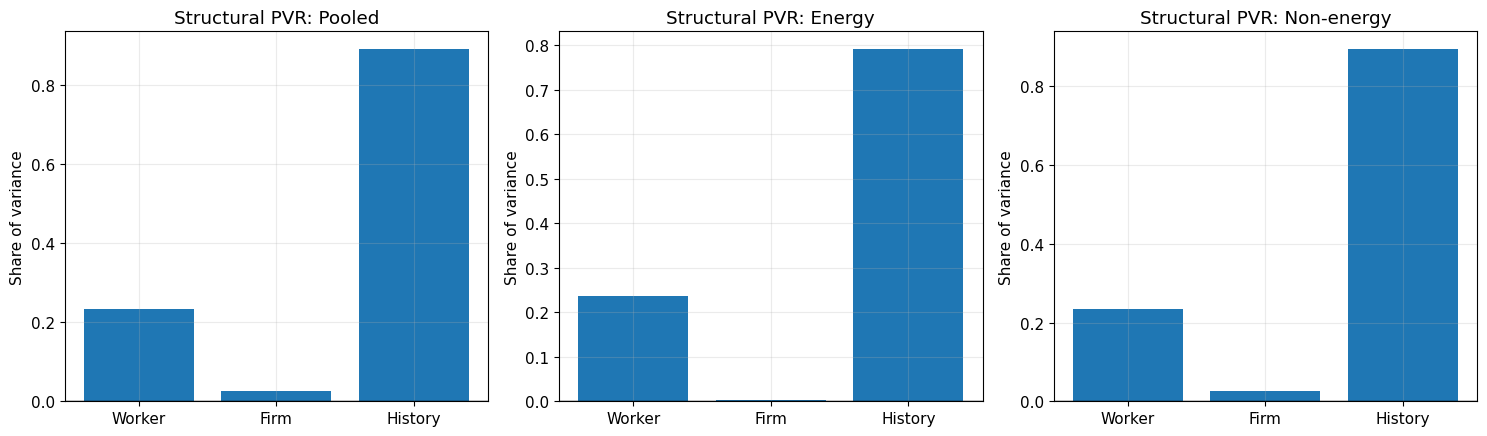

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, sSector in zip(axes, ["Pooled", "Energy", "Non-energy"]):
    sr = dtStructDecomp.loc[dtStructDecomp["sector_name"] == sSector].iloc[0]
    vVals = [sr["share_worker_struct"], sr["share_firm_struct"], sr["share_history_struct"]]
    ax.bar(["Worker", "Firm", "History"], vVals)
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_title(f"Structural PVR: {sSector}")
    ax.set_ylabel("Share of variance")

plt.tight_layout()
plt.show()

---
## 8. AKM bridge: estimate AKM on simulated PVR wages
---

Now we run AKM directly on the simulated log wage panel:

$$
\log w_{it}^{sim}=\alpha_i^{AKM}+\psi_{j(i,t)}^{AKM}+e_{it}^{AKM}.
$$


In [152]:
def largest_connected_component_worker_firm(df, worker_col="worker_id", firm_col="firm_id"):
    dtEdges = df[[worker_col, firm_col]].drop_duplicates()

    dWorkerToFirms = dtEdges.groupby(worker_col)[firm_col].apply(list).to_dict()
    dFirmToWorkers = dtEdges.groupby(firm_col)[worker_col].apply(list).to_dict()

    sUnseenWorkers = set(dWorkerToFirms.keys())
    lComponents = []

    while len(sUnseenWorkers) > 0:
        iStartWorker = sUnseenWorkers.pop()
        qNodes = deque([("worker", iStartWorker)])
        sCompWorkers = set()
        sCompFirms = set()

        while len(qNodes) > 0:
            sType, iNode = qNodes.popleft()

            if sType == "worker":
                if iNode in sCompWorkers:
                    continue
                sCompWorkers.add(iNode)
                for iFirm in dWorkerToFirms.get(iNode, []):
                    if iFirm not in sCompFirms:
                        qNodes.append(("firm", iFirm))

            else:
                if iNode in sCompFirms:
                    continue
                sCompFirms.add(iNode)
                for iWorker in dFirmToWorkers.get(iNode, []):
                    if iWorker in sUnseenWorkers:
                        sUnseenWorkers.remove(iWorker)
                        qNodes.append(("worker", iWorker))
                    elif iWorker not in sCompWorkers:
                        qNodes.append(("worker", iWorker))

        lComponents.append((sCompWorkers, sCompFirms))

    sLargestWorkers, sLargestFirms = max(lComponents, key=lambda x: (len(x[0]), len(x[1])))

    dtOut = df.loc[
        df[worker_col].isin(sLargestWorkers) & df[firm_col].isin(sLargestFirms)
    ].copy()

    return dtOut, len(lComponents)

In [153]:
def fit_akm(df, y_col="log_wage", worker_col="worker_id", firm_col="firm_id", max_iter=1_000, tol=1e-10):
    '''
    Estimate additive worker and firm effects using alternating projections.
    This is sufficient for the simulated panel and keeps the notebook readable.
    '''
    vY = df[y_col].to_numpy(dtype=float)

    idxWorkers = pd.Index(sorted(df[worker_col].unique()))
    idxFirms = pd.Index(sorted(df[firm_col].unique()))

    dWorkerMap = {old: new for new, old in enumerate(idxWorkers)}
    dFirmMap = {old: new for new, old in enumerate(idxFirms)}

    vWorkerCodes = df[worker_col].map(dWorkerMap).to_numpy()
    vFirmCodes = df[firm_col].map(dFirmMap).to_numpy()

    vAlpha = np.zeros(len(idxWorkers))
    vPsi = np.zeros(len(idxFirms))

    for _ in range(max_iter):
        vAlphaNew = (
            pd.Series(vY - vPsi[vFirmCodes])
            .groupby(vWorkerCodes, sort=False)
            .mean()
            .reindex(range(len(idxWorkers)), fill_value=0.0)
            .to_numpy()
        )

        vPsiRaw = (
            pd.Series(vY - vAlphaNew[vWorkerCodes])
            .groupby(vFirmCodes, sort=False)
            .mean()
            .reindex(range(len(idxFirms)), fill_value=0.0)
            .to_numpy()
        )

        # Normalization: average firm effect is zero.
        dShift = vPsiRaw.mean()
        vPsiNew = vPsiRaw - dShift
        vAlphaNew = vAlphaNew + dShift

        dGap = max(np.max(np.abs(vAlphaNew - vAlpha)), np.max(np.abs(vPsiNew - vPsi)))
        vAlpha = vAlphaNew
        vPsi = vPsiNew

        if dGap < tol:
            break

    vResid = vY - vAlpha[vWorkerCodes] - vPsi[vFirmCodes]

    return {
        "alpha": vAlpha,
        "psi": vPsi,
        "alpha_obs": vAlpha[vWorkerCodes],
        "psi_obs": vPsi[vFirmCodes],
        "resid": vResid,
        "workers": idxWorkers,
        "firms": idxFirms,
    }


def akm_decomp_from_columns(dtSub, y_col, alpha_col, psi_col, resid_col):
    dVarY = dtSub[y_col].var(ddof=0)
    dVarWorker = dtSub[alpha_col].var(ddof=0)
    dVarFirm = dtSub[psi_col].var(ddof=0)
    dTwoCov = 2.0 * np.cov(dtSub[alpha_col], dtSub[psi_col], ddof=0)[0, 1]
    dVarResid = dtSub[resid_col].var(ddof=0)

    return {
        "var_y": dVarY,
        "share_worker_akm": dVarWorker / dVarY,
        "share_firm_akm": dVarFirm / dVarY,
        "share_sorting_akm": dTwoCov / dVarY,
        "share_resid_akm": dVarResid / dVarY,
        "share_total_akm": (dVarWorker + dVarFirm + dTwoCov + dVarResid) / dVarY,
    }

In [154]:
dtAKMSim = dtPanel[[
    "month", "worker_id", "worker_type", "eps", "sector", "sector_name",
    "firm_id", "p_current", "q_current", "log_wage", "wage"
]].copy()

dtAKMSimLCC, iNumComponents = largest_connected_component_worker_firm(
    dtAKMSim,
    worker_col="worker_id",
    firm_col="firm_id",
)

dtAKMSimOverview = pd.DataFrame({
    "object": [
        "Employed simulated observations",
        "Workers in employed sample",
        "Firms in employed sample",
        "Connected components in employed sample",
        "Employed observations in LCC",
        "Workers in LCC",
        "Firms in LCC",
    ],
    "value": [
        len(dtAKMSim),
        dtAKMSim["worker_id"].nunique(),
        dtAKMSim["firm_id"].nunique(),
        iNumComponents,
        len(dtAKMSimLCC),
        dtAKMSimLCC["worker_id"].nunique(),
        dtAKMSimLCC["firm_id"].nunique(),
    ]
})

dtAKMSimOverview

,object,value
0,Employed simulated observations,349286
1,Workers in employed sample,4000
2,Firms in employed sample,1000
3,Connected components in employed sample,1
4,Employed observations in LCC,349286
5,Workers in LCC,4000
6,Firms in LCC,1000


In [155]:
resAKMSim = fit_akm(
    dtAKMSimLCC,
    y_col="log_wage",
    worker_col="worker_id",
    firm_col="firm_id",
)

dtAKMSimLCC["alpha_hat_akm"] = resAKMSim["alpha_obs"]
dtAKMSimLCC["psi_hat_akm"] = resAKMSim["psi_obs"]
dtAKMSimLCC["resid_hat_akm"] = resAKMSim["resid"]

lAKMRows = []
for sName, dtSub in [("Pooled", dtAKMSimLCC)] + list(dtAKMSimLCC.groupby("sector_name")):
    dOut = akm_decomp_from_columns(
        dtSub,
        y_col="log_wage",
        alpha_col="alpha_hat_akm",
        psi_col="psi_hat_akm",
        resid_col="resid_hat_akm",
    )
    dOut["sector_name"] = sName
    lAKMRows.append(dOut)

dtAKMSimResults = pd.DataFrame(lAKMRows)
dtAKMSimResults = dtAKMSimResults[[
    "sector_name",
    "var_y",
    "share_worker_akm",
    "share_firm_akm",
    "share_sorting_akm",
    "share_resid_akm",
    "share_total_akm",
]]

dtAKMSimResults

,sector_name,var_y,share_worker_akm,share_firm_akm,share_sorting_akm,share_resid_akm,share_total_akm
0,Pooled,3.144510,0.439925,0.242439,-0.075503,0.393140,1.000000
1,Energy,3.272428,0.467164,0.130348,-0.066774,0.450926,0.981664
2,Non-energy,3.117193,0.440986,0.244591,-0.076410,0.391986,1.001153


### 8.1 Compare simulated AKM to empirical AKM targets

In [157]:
dtModelMeanWage = (
    dtAKMSimLCC
    .groupby("sector_name")["log_wage"]
    .agg(["mean", "std"])
    .reset_index()
)

def get_sector_mean(sSector):
    v = dtModelMeanWage.loc[dtModelMeanWage["sector_name"] == sSector, "mean"]
    return np.nan if len(v) == 0 else v.iloc[0]

dMeanEnergyModel = get_sector_mean("Energy")
dMeanNonEnergyModel = get_sector_mean("Non-energy")

dtCompareMeanWage = pd.DataFrame({
    "sector_name": ["Energy", "Non-energy"],
    "mean_log_wage_data": [dTarget_mean_log_wage_energy, dTarget_mean_log_wage_nonenergy],
    "mean_log_wage_model": [dMeanEnergyModel, dMeanNonEnergyModel],
})

dtCompareMeanWage["gap_model_minus_data"] = dtCompareMeanWage["mean_log_wage_model"] - dtCompareMeanWage["mean_log_wage_data"]
dtCompareMeanWage["relative_energy_gap_data"] = dTarget_mean_log_wage_energy - dTarget_mean_log_wage_nonenergy
dtCompareMeanWage["relative_energy_gap_model"] = dMeanEnergyModel - dMeanNonEnergyModel

dtCompareMeanWage

,sector_name,mean_log_wage_data,mean_log_wage_model,gap_model_minus_data,relative_energy_gap_data,relative_energy_gap_model
0,Energy,5.097629,1.107393,-3.990236,0.348686,-0.589806
1,Non-energy,4.748943,1.697199,-3.051744,0.348686,-0.589806


In [158]:
def get_akm_moment(sSector, sCol):
    v = dtAKMSimResults.loc[dtAKMSimResults["sector_name"] == sSector, sCol]
    return np.nan if len(v) == 0 else v.iloc[0]

dtCompareAKM = pd.DataFrame({
    "sector_name": ["Energy", "Non-energy"],
    "worker_share_data": [dTarget_worker_share_energy, dTarget_worker_share_nonenergy],
    "worker_share_model": [
        get_akm_moment("Energy", "share_worker_akm"),
        get_akm_moment("Non-energy", "share_worker_akm"),
    ],
    "firm_share_data": [dTarget_firm_share_energy, dTarget_firm_share_nonenergy],
    "firm_share_model": [
        get_akm_moment("Energy", "share_firm_akm"),
        get_akm_moment("Non-energy", "share_firm_akm"),
    ],
    "sorting_data": [dTarget_sorting_energy, dTarget_sorting_nonenergy],
    "sorting_model": [
        get_akm_moment("Energy", "share_sorting_akm"),
        get_akm_moment("Non-energy", "share_sorting_akm"),
    ],
})

dtCompareAKM["worker_gap_model_minus_data"] = dtCompareAKM["worker_share_model"] - dtCompareAKM["worker_share_data"]
dtCompareAKM["firm_gap_model_minus_data"] = dtCompareAKM["firm_share_model"] - dtCompareAKM["firm_share_data"]
dtCompareAKM["sorting_gap_model_minus_data"] = dtCompareAKM["sorting_model"] - dtCompareAKM["sorting_data"]

dtCompareAKM

,sector_name,worker_share_data,worker_share_model,firm_share_data,firm_share_model,sorting_data,sorting_model,worker_gap_model_minus_data,firm_gap_model_minus_data,sorting_gap_model_minus_data
0,Energy,0.805977,0.467164,0.061156,0.130348,-0.060900,-0.066774,-0.338813,0.069192,-0.005874
1,Non-energy,0.549511,0.440986,0.188010,0.244591,0.081121,-0.076410,-0.108525,0.056581,-0.157531


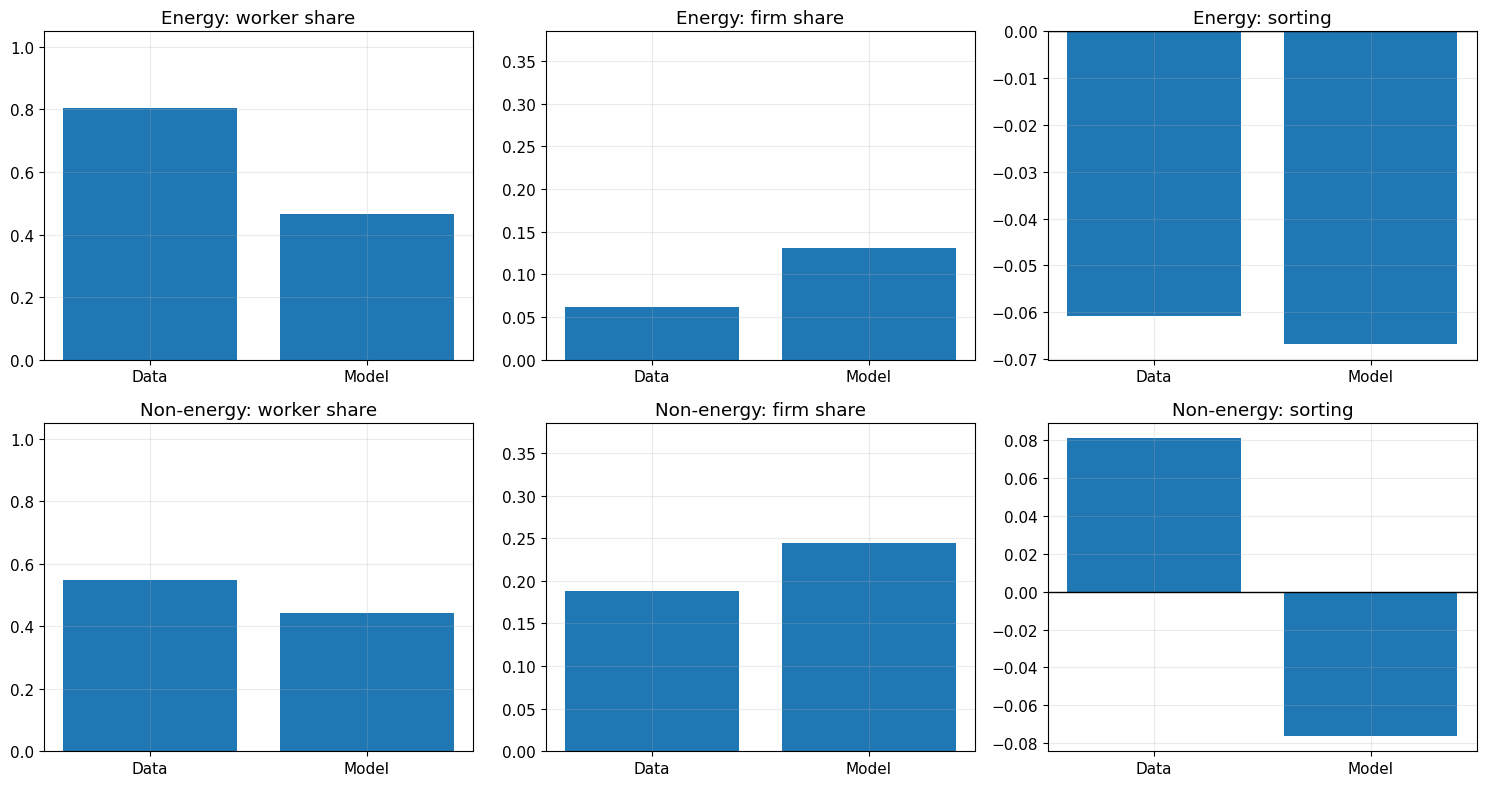

In [159]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, sSector in enumerate(["Energy", "Non-energy"]):
    sr = dtCompareAKM.loc[dtCompareAKM["sector_name"] == sSector].iloc[0]

    axes[i, 0].bar(["Data", "Model"], [sr["worker_share_data"], sr["worker_share_model"]])
    axes[i, 0].set_title(f"{sSector}: worker share")
    axes[i, 0].set_ylim(0, max(1.0, sr["worker_share_data"], sr["worker_share_model"]) * 1.05)

    axes[i, 1].bar(["Data", "Model"], [sr["firm_share_data"], sr["firm_share_model"]])
    axes[i, 1].set_title(f"{sSector}: firm share")
    axes[i, 1].set_ylim(0, max(0.35, sr["firm_share_data"], sr["firm_share_model"]) * 1.10)

    axes[i, 2].bar(["Data", "Model"], [sr["sorting_data"], sr["sorting_model"]])
    axes[i, 2].axhline(0.0, color="black", linewidth=1)
    axes[i, 2].set_title(f"{sSector}: sorting")

plt.tight_layout()
plt.show()

---
## 9. Summary and interpretation
---

This final table keeps the two decompositions separate.

In [119]:
def get_struct_moment(sSector, sCol):
    v = dtStructDecomp.loc[dtStructDecomp["sector_name"] == sSector, sCol]
    return np.nan if len(v) == 0 else v.iloc[0]

def get_firm_dispersion(sSector):
    v = dtFirmDispersion.loc[dtFirmDispersion["sector_name"] == sSector, "std"]
    return np.nan if len(v) == 0 else v.iloc[0]

dtSummary = pd.DataFrame({
    "object": [
        "Empirical Energy worker share",
        "Empirical Energy firm share",
        "Empirical Energy sorting",
        "Structural Energy worker share",
        "Structural Energy firm share",
        "Structural Energy history share",
        "AKM-simulated Energy worker share",
        "AKM-simulated Energy firm share",
        "AKM-simulated Energy sorting",
        "Firm productivity sd: Energy",
        "Firm productivity sd: Non-energy",
        "Common worker distribution",
        "Ability-dependent Energy access",
    ],
    "value": [
        dTarget_worker_share_energy,
        dTarget_firm_share_energy,
        dTarget_sorting_energy,
        get_struct_moment("Energy", "share_worker_struct"),
        get_struct_moment("Energy", "share_firm_struct"),
        get_struct_moment("Energy", "share_history_struct"),
        get_akm_moment("Energy", "share_worker_akm"),
        get_akm_moment("Energy", "share_firm_akm"),
        get_akm_moment("Energy", "share_sorting_akm"),
        get_firm_dispersion("Energy"),
        get_firm_dispersion("Non-energy"),
        "Yes: common H",
        "No",
    ]
})

dtSummary

,object,value
0,Empirical Energy worker share,0.805977
1,Empirical Energy firm share,0.061156
2,Empirical Energy sorting,-0.0609
3,Structural Energy worker share,0.236605
4,Structural Energy firm share,0.002094
5,Structural Energy history share,0.791343
6,AKM-simulated Energy worker share,0.467164
7,AKM-simulated Energy firm share,0.130348
8,AKM-simulated Energy sorting,-0.066774
9,Firm productivity sd: Energy,0.158986


### Main interpretation

The model should be read as a conservative structural rationalization. It allows Energy and Non-energy to differ in firm productivity dispersion, but it does not allow Energy to have a different worker ability distribution. Therefore, if the model cannot match the high Energy worker component, this is an informative limitation rather than a failure of coding.

The central comparison is:

1. **Structural PVR decomposition:** what the model says about worker ability, current-firm productivity, and history/outside-option variation.
2. **AKM on simulated wages:** what an AKM regression would recover if the model generated the data.
3. **Empirical AKM:** what the real data show.

